In [ ]:
import numpy as np
import scipy
import scipy.io as sio
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import os
import time

from glmsingle import GLM_single
from glob import glob
from os.path import join, exists, split
from nilearn.glm.first_level import first_level_from_bids
from nilearn.interfaces.fmriprep import load_confounds

## Set up modeling

In [ ]:

def update_events(models_events, event_type='sound'):
    ''' create events '''
    # stimulus events
    if event_type == 'stimulus':
        for sx, sub_events in enumerate(models_events):
            for mx, run_events in enumerate(sub_events):
                run_events['trial_type'] = run_events['trial_type'].str.replace('-','_')

                # remove NaNs
                run_events.dropna(subset=['onset'], inplace=True)

        # create stimulus list from updated events.tsv file
        stim_list = sorted([s for s in run_events['trial_type'].unique() if str(s) != 'nan'])
    
    # trial-specific events
    if event_type == 'trial':
        for sx, sub_events in enumerate(models_events):
            for mx, run_events in enumerate(sub_events):

                name_groups = run_events.groupby('trial_type')['trial_type']
                suffix = name_groups.cumcount() + 1
                repeats = name_groups.transform('size')

                run_events['trial_type'] = run_events['trial_type'] + \
                                                    '_trial' + suffix.map(str)
                run_events['trial_type'] = run_events['trial_type'].str.replace('-','_')
                
                # remove NaNs
                run_events.dropna(subset=['onset'], inplace=True)

        # create stimulus list from updated events.tsv file
        stim_list = sorted([s for s in run_events['trial_type'].unique() if str(s) != 'nan'])

    # all sound events
    if event_type == 'sound':
        for sx, sub_events in enumerate(models_events):
            for mx, run_events in enumerate(sub_events):
                orig_stim_list = sorted([str(s) for s in run_events['trial_type'].unique() if str(s) not in ['nan', 'None']])
                print('original stim list: ', orig_stim_list)

                run_events['trial_type'] = run_events.trial_type.str.split('_', 
                                                                           expand=True)[0]

                # remove NaNs
                run_events.dropna(subset=['onset'], inplace=True)

        # create stimulus list from updated events.tsv file
        stim_list = sorted([str(s) for s in run_events['trial_type'].unique() if str(s) not in ['nan', 'None']])
        print('stim list: ', stim_list)
        
    return stim_list, models_events

In [ ]:
def convert_events_to_glmsingle_matrices(models_events, tr, n_trs_per_run):
    """
    Convert nested models_events from Nilearn into GLMsingle-compatible event matrices.

    Parameters:
    - models_events: list of list of pd.DataFrame (runs per subject)
    - tr: float, repetition time in seconds
    - n_trs_per_run: int, number of TRs per run

    Returns:
    - List of np.ndarray, each shaped [n_TRs × n_trials]
    """
    glmsingle_matrices = []

    for subject_runs in models_events:
        for run_events in subject_runs:
            n_trials = len(run_events)
            design_matrix = np.zeros((n_trs_per_run, n_trials))

            for i, onset in enumerate(run_events['onset'].values):
                onset_tr = int(np.round(onset / tr))
                if onset_tr < n_trs_per_run:
                    design_matrix[onset_tr, i] = 1

            glmsingle_matrices.append(design_matrix)

    return glmsingle_matrices


In [ ]:
def convert_events_grouped_by_condition(models_events, tr, n_trs_per_run):
    """
    Convert models_events into GLMsingle-compatible design matrices grouped by 'sound' conditions.

    Parameters:
    - models_events: list of list of pd.DataFrame
    - tr: float, repetition time
    - n_trs_per_run: int, number of TRs per run

    Returns:
    - List of np.ndarray, each shaped [n_TRs × n_conditions]
    - List of condition names per run
    """
    glmsingle_matrices = []
    condition_names_per_run = []

    for subject_runs in models_events:
        for run_events in subject_runs:
            # Filter to only 'sound' trials
            sound_mask = run_events['trial_type'].str.contains('sound')
            sound_events = run_events[sound_mask]
            condition_names = sorted(sound_events['trial_type'].unique())

            # Initialize design matrix
            design_matrix = np.zeros((n_trs_per_run, len(condition_names)))

            # Fill matrix: 1 at onset TR for each condition
            for _, row in sound_events.iterrows():
                onset_tr = int(np.round(row['onset'] / tr))
                if onset_tr < n_trs_per_run:
                    cond_idx = condition_names.index(row['trial_type'])
                    design_matrix[onset_tr, cond_idx] = 1

            glmsingle_matrices.append(design_matrix)
            condition_names_per_run.append(condition_names)

    return glmsingle_matrices, condition_names_per_run


In [ ]:
task_label  = 'tonecat'
space_label = 'MNI152NLin2009cAsym'
event_type  = 'stimulus' # 'snr', 'sound'

t_acq = 2
t_r = t_acq + 1 # same as t_acq since no silent gap in this acquisition

# correct the fmriprep-given slice reference (middle slice, or 0.5)
slice_time_ref = 0.5 * t_acq / t_r

# define bids and fmriprep directories
project_dir = os.path.join('/ix1/bchandrasekaran/krs228/data/', 
                           'FLT/')
bidsroot = os.path.join(project_dir, 
                        'data_denoised')
fmriprep_dir = os.path.join(bidsroot, 
                            'derivatives', 
                            'denoised_fmriprep-22.1.1',
                            )
print('bidsroot: ', bidsroot)
print('fmriprep dir:', fmriprep_dir)

# create output directory
bidsderiv_dir = os.path.join(bidsroot, 
                             'derivatives', 
                             'glmsingle', 
                             'subject_level')
if not os.path.exists(bidsderiv_dir):
    os.makedirs(bidsderiv_dir)
print('bidsderiv dir:', bidsderiv_dir)

## Create models (single participant)

In [ ]:
fwhm = 0
subject_list = ['FLT02']


In [ ]:
subject_id = subject_list[0]
models, models_run_imgs, \
        raw_models_events, \
        models_confounds = first_level_from_bids(bidsroot, 
                                                 task_label, 
                                                 space_label=space_label,
                                                 sub_labels=[subject_id],
                                                 smoothing_fwhm=fwhm,
                                                 derivatives_folder=fmriprep_dir,
                                                 slice_time_ref=slice_time_ref,
                                                 minimize_memory=False)


In [ ]:
# create updated events dataframes
stim_list, models_events = update_events(raw_models_events, 
                                         event_type=event_type)


In [ ]:
models

In [ ]:
models_run_imgs

In [ ]:
models_events[0][0]

## Implement GLMsingle

https://github.com/cvnlab/GLMsingle/blob/main/examples/example3_BIDS.ipynb

In [ ]:

# create a directory for saving GLMsingle outputs
outputdir_glmsingle = os.path.join(bidsderiv_dir, f'sub-{subject_id}')

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 1
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameters
print(glmsingle_obj.params)

In [ ]:
data = [nib.load(x).get_fdata() for x in models_run_imgs[0]]
design = models_events[0]
stimdur = 0.3

tr = t_r
n_trs_per_run = data[0].shape[3]

In [ ]:
xyz = data[0].shape[:3]
print(xyz)

In [ ]:
[x.shape for x in data]

In [ ]:
print('TR (in s):', t_r)
print('# TRs:', n_trs_per_run)
glmsingle_matrices, condition_names = convert_events_grouped_by_condition(models_events, t_r, n_trs_per_run)

In [ ]:
[x.shape for x in glmsingle_matrices]

In [ ]:
[print(x.sum(0)) for x in glmsingle_matrices]

In [ ]:
glmsingle_matrices[0]

In [ ]:
binary_matrix = glmsingle_matrices[0]
rows, cols = binary_matrix.shape

figsize_width = cols * 0.5  # Adjust multiplier for desired width
figsize_height = rows * 0.05 # Adjust multiplier for desired height

plt.figure(figsize=(figsize_width, figsize_height)) 

plt.imshow(binary_matrix, cmap='Greys', interpolation='nearest', aspect='auto')
plt.xticks([])

plt.xlabel('stimulus token')
plt.ylabel('BOLD volume/TR')
plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

In [ ]:
design[5]

#### Run GLMsingle for one participant

In [21]:
start_time = time.time()


if not os.path.exists(outputdir_glmsingle):

    print(f'running GLMsingle...')
    
    # run GLMsingle
    results_glmsingle = glmsingle_obj.fit(
       glmsingle_matrices,
       data,
       stimdur,
       tr,
       outputdir=outputdir_glmsingle)
    
    # we assign outputs of GLMsingle to the "results_glmsingle" variable.
    # note that results_glmsingle['typea'] contains GLM estimates from an ONOFF model,
    # where all images are treated as the same condition. these estimates
    # could be potentially used to find cortical areas that respond to
    # visual stimuli. we want to compare beta weights between conditions
    # therefore we are not going to include the ONOFF betas in any analyses of 
    # voxel reliability
    
else:
    print(f'loading existing GLMsingle outputs from directory:\n\t{outputdir_glmsingle}')
    
    # load existing file outputs if they exist
    results_glmsingle = dict()
    results_glmsingle['typea'] = np.load(join(outputdir_glmsingle,'TYPEA_ONOFF.npy'),allow_pickle=True).item()
    results_glmsingle['typeb'] = np.load(join(outputdir_glmsingle,'TYPEB_FITHRF.npy'),allow_pickle=True).item()
    results_glmsingle['typec'] = np.load(join(outputdir_glmsingle,'TYPEC_FITHRF_GLMDENOISE.npy'),allow_pickle=True).item()
    results_glmsingle['typed'] = np.load(join(outputdir_glmsingle,'TYPED_FITHRF_GLMDENOISE_RR.npy'),allow_pickle=True).item()

elapsed_time = time.time() - start_time

print(
    '\telapsed time: ',
    f'{time.strftime("%H:%M:%S", time.gmtime(elapsed_time))}'
)

running GLMsingle...
*** DIAGNOSTICS ***:
There are 6 runs.
The number of conditions in this experiment is 16.
The stimulus duration corresponding to each trial is 0.30 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [48, 48, 48, 48, 48, 48].
The number of trials for each condition is: [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18].
For each condition, the number of runs in which it appears: [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6].
For each run, how much ending buffer do we have in seconds? [18, 18, 30, 24, 24, 18].
*** Saving design-related results to /ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT02/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT02/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing out

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
chunks:   0%|          | 0/43 [00:00<?, ?it/s]

*** Setting brain R2 threshold to 0.2379464493549027 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 43/43 [16:26<00:00, 22.95s/it]



*** Saving results to /ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT02/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***



chunks:   0%|          | 0/43 [00:00<?, ?it/s]

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks:   0%|          | 0/43 [00:00<?, ?it/s]


*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 43/43 [07:42<00:00, 10.76s/it]



*** Saving results to /ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT02/TYPEC_FITHRF_GLMDENOISE.npy. ***



chunks:   0%|          | 0/43 [00:00<?, ?it/s]

*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 43/43 [1:12:11<00:00, 100.73s/it]



*** Saving results to /ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT02/TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***

	elapsed time:  02:00:21


In [22]:

print(
    '\telapsed time: ',
    f'{time.strftime("%H:%M:%S", time.gmtime(elapsed_time))}'
)

	elapsed time:  02:00:21


## Plot GLMsingle outputs

In [ ]:
from nilearn.image import new_img_like
from nilearn.plotting import view_img, plot_stat_map

In [ ]:
# we are going to plot several outputs from the FIT_HRF_GLMdenoise_RR GLM,
# which contains the full set of GLMsingle optimizations.

# we will plot betas, R2, optimal HRF indices, and the voxel frac values
plot_fields = ['betasmd','R2','HRFindex','FRACvalue']
colormaps = ['RdBu_r','hot','jet','copper']
clims = [[-5,5],[0,85],[0,20],[0,1]]

In [ ]:
participant_list = sorted(os.listdir(bidsderiv_dir))

In [ ]:
sub_id = participant_list[1]

sub_glmsingle_dir = os.path.join(bidsderiv_dir, sub_id)

# load existing file outputs if they exist
results_glmsingle = dict()
results_glmsingle['typea'] = np.load(join(sub_glmsingle_dir,'TYPEA_ONOFF.npy'),allow_pickle=True).item()
results_glmsingle['typeb'] = np.load(join(sub_glmsingle_dir,'TYPEB_FITHRF.npy'),allow_pickle=True).item()
results_glmsingle['typec'] = np.load(join(sub_glmsingle_dir,'TYPEC_FITHRF_GLMDENOISE.npy'),allow_pickle=True).item()
results_glmsingle['typed'] = np.load(join(sub_glmsingle_dir,'TYPED_FITHRF_GLMDENOISE_RR.npy'),allow_pickle=True).item()


In [ ]:
results_glmsingle.keys()

In [ ]:
results_glmsingle['typed'].keys()

In [ ]:
results_glmsingle['typed']['betasmd']

In [ ]:
plot_data = np.squeeze(results_glmsingle['typea'][plot_fields[0]])
typea_img = new_img_like(models_run_imgs[0], plot_data)

/scratch/slurm-6835921/ipykernel_74302/1577589860.py:1: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  view_img(typea_img,
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



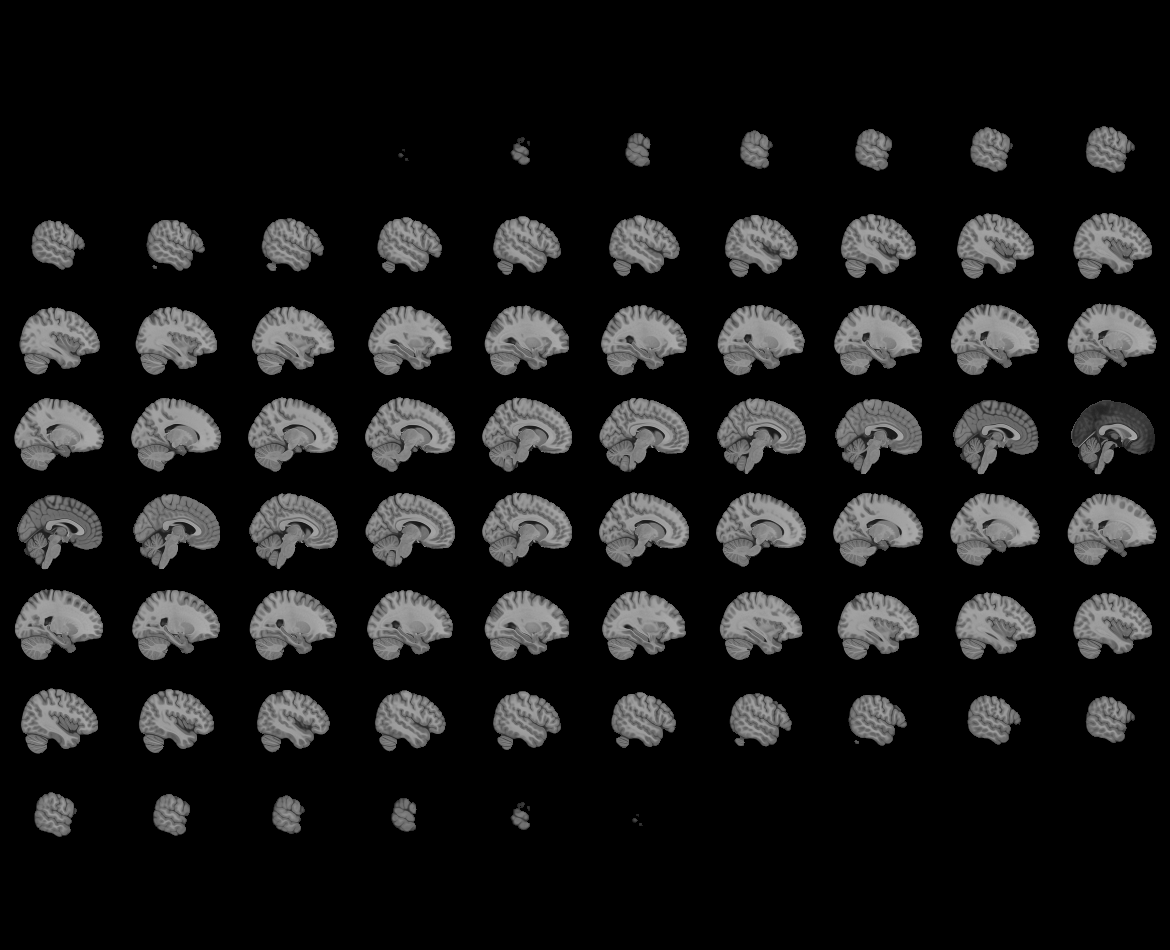
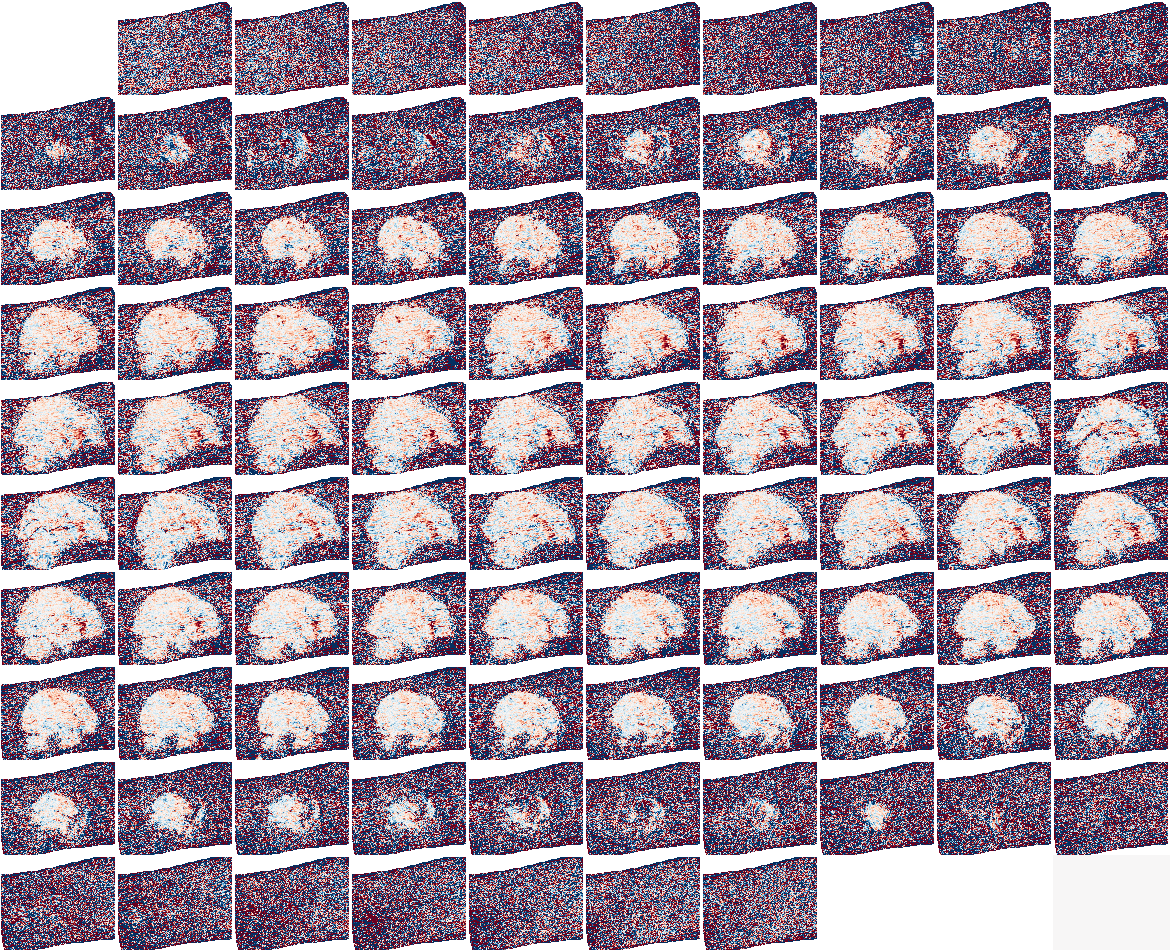

In [23]:
view_img(typea_img, 
         title='Type A ONOFF model',
         symmetric_cmap=False, vmin=-2, vmax=2, 
         cut_coords=[-50,-20,15],
        width_view=1000)

In [24]:
plot_data = np.nanmean(np.squeeze(results_glmsingle['typed'][plot_fields[0]]),3)
beta_mean_img = new_img_like(models_run_imgs[0], plot_data)

/scratch/slurm-6835921/ipykernel_74302/2522188494.py:1: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  view_img(beta_mean_img,
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



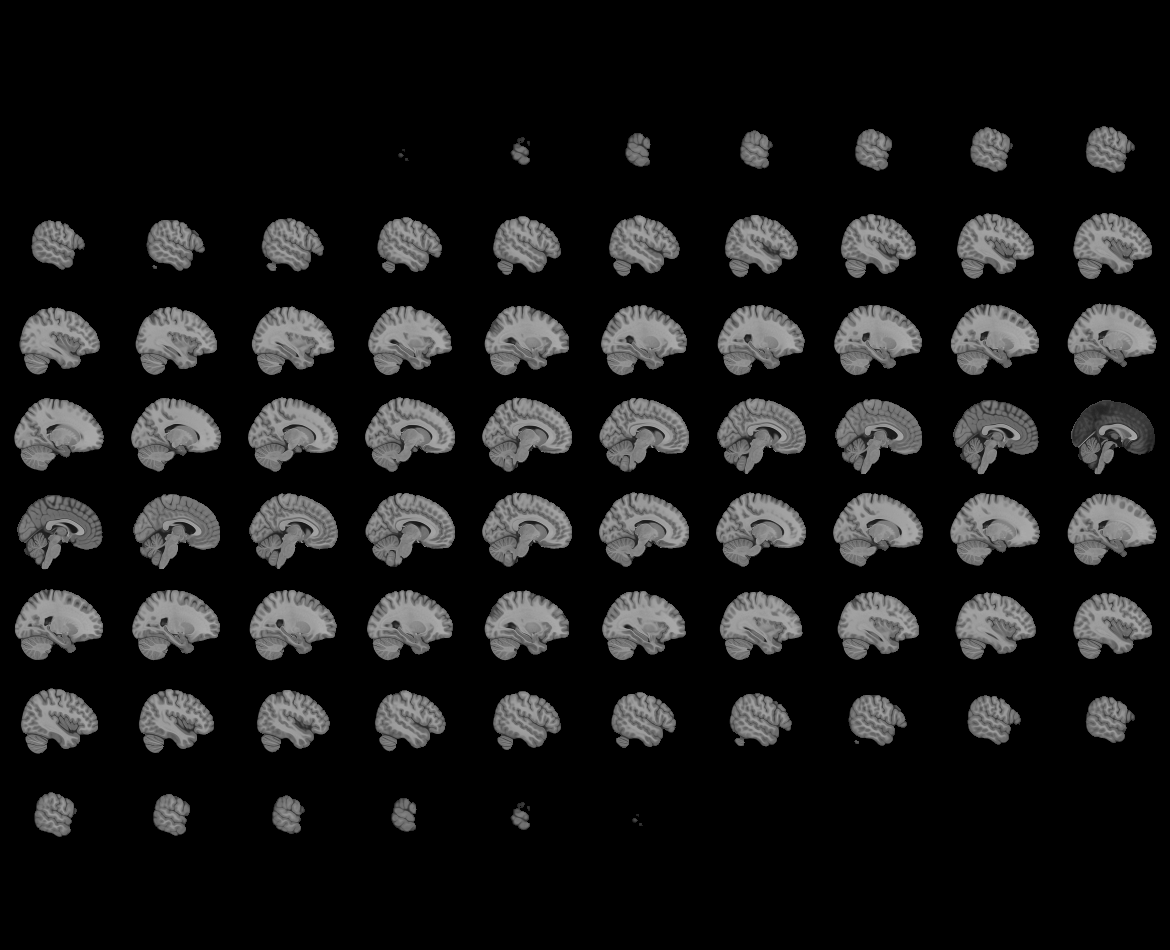
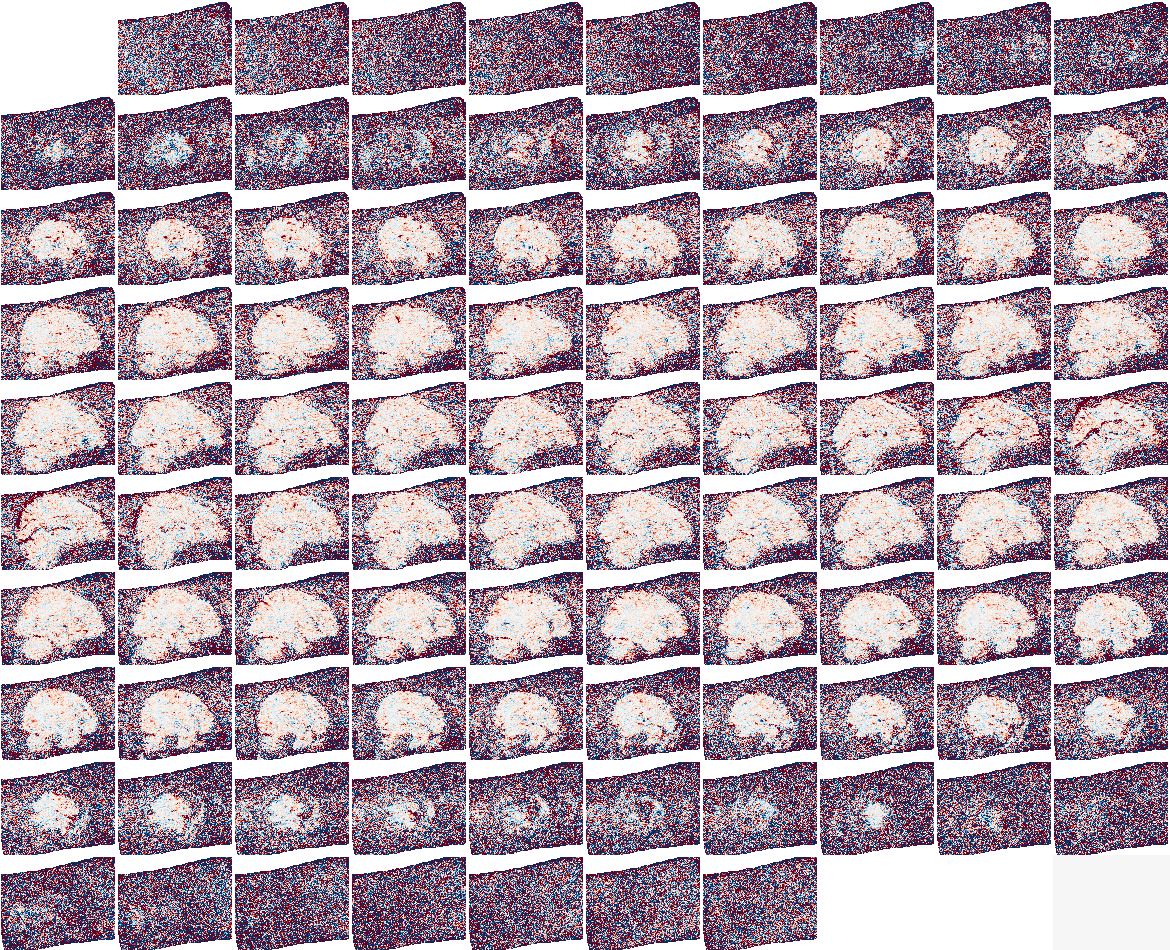

In [25]:
view_img(beta_mean_img, 
         title='TYPED_FITHRF_GLMDENOISE_RR beta mean',
         symmetric_cmap=False, vmin=-2, vmax=2, 
         cut_coords=[-50,-20,15],
        width_view=1000)

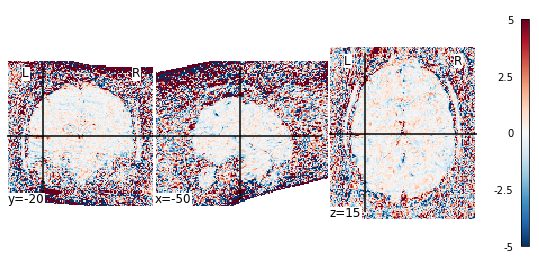

In [63]:
plot_stat_map(beta_mean_img, vmax=5,
              cut_coords=[-50,-20,15])

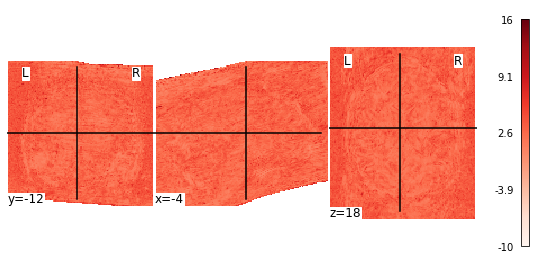

In [84]:
plot_data = np.squeeze(results_glmsingle['typed'][plot_fields[1]].reshape(xyz))
r2_img = new_img_like(models_run_imgs[0], plot_data)

plot_stat_map(r2_img, symmetric_cbar=False, cmap='Reds')

/scratch/slurm-6779027/ipykernel_913412/199007805.py:2: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  glmsingle_img = new_img_like(models_run_imgs[0], plot_data)


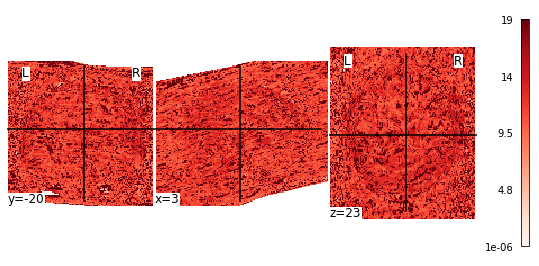

In [34]:
plot_data = np.squeeze(results_glmsingle['typed'][plot_fields[2]].reshape(xyz))
glmsingle_img = new_img_like(models_run_imgs[0], plot_data)

plot_stat_map(glmsingle_img, symmetric_cbar=False, cmap='Reds')

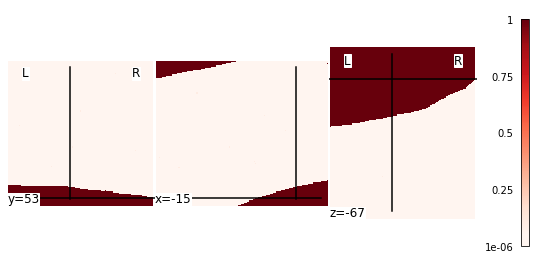

In [31]:
plot_data = np.squeeze(results_glmsingle['typed'][plot_fields[3]].reshape(xyz))
glmsingle_img = new_img_like(models_run_imgs[0], plot_data)

plot_stat_map(glmsingle_img, symmetric_cbar=False, cmap='Reds')

In [ ]:
# we are going to plot several outputs from the FIT_HRF_GLMdenoise_RR GLM,
# which contains the full set of GLMsingle optimizations.

# we will plot betas, R2, optimal HRF indices, and the voxel frac values
plot_fields = ['betasmd','R2','HRFindex','FRACvalue']
colormaps = ['RdBu_r','hot','jet','copper']
clims = [[-5,5],[0,85],[0,20]] # ,[0,1]
plt.figure(figsize=(12,8))

for i in range(len(plot_fields)):
    
    plt.subplot(2,2,i+1)
    
    if i == 0:
        # when plotting betas, for simplicity just average across all image presentations
        # this will yield a summary of whether voxels tend to increase or decrease their 
        # activity in response to the experimental stimuli (similar to outputs from 
        # an ONOFF GLM)
        plot_data = np.nanmean(np.squeeze(results_glmsingle['typed'][plot_fields[i]]),2)
        titlestr = 'average GLM betas (200 stimuli)'
    
    else:
        # plot all other voxel-wise metrics as outputted from GLMsingle
        plot_data = np.squeeze(results_glmsingle['typed'][plot_fields[i]].reshape(xyz))
        titlestr = plot_fields[i]
    
    plt.imshow(plot_data,cmap=colormaps[i],interpolation='nearest') # clim=clims[i],
    plt.colorbar()
    plt.title(titlestr)
    plt.axis(False)

In [ ]:
plot_data.shape

## Re-load and save GLMSingle outputs as nifti images

In [45]:
n_reps = 3
print(n_reps, "repetitions per stimulus")

n_stim = len(condition_names[0])
print(n_stim, "stimuli")

n_runs = len(condition_names)
print(n_runs, 'runs')

assert betasmd.shape[3] == n_runs * n_stim * n_reps   # 288

3 repetitions per stimulus
16 stimuli
6 runs


In [67]:
models, models_run_imgs, \
        raw_models_events, \
        models_confounds = first_level_from_bids(bidsroot, 
                                                 task_label, 
                                                 space_label=space_label,
                                                 smoothing_fwhm=fwhm,
                                                 derivatives_folder=fmriprep_dir,
                                                 slice_time_ref=slice_time_ref,
                                                 minimize_memory=False)

/scratch/slurm-7041349/ipykernel_2037776/2210653425.py:3: UserWarning: 'slice_time_ref' provided (0.3333333333333333) is different from the value found in the BIDS dataset (0.3233333333333333).
Note this may lead to the wrong model specification.
  models_confounds = first_level_from_bids(bidsroot,


In [68]:
len(models)

26

In [74]:
sorted(os.listdir(bidsderiv_dir))

['sub-FLT02',
 'sub-FLT03',
 'sub-FLT04',
 'sub-FLT05',
 'sub-FLT07',
 'sub-FLT08',
 'sub-FLT09',
 'sub-FLT10',
 'sub-FLT11',
 'sub-FLT12',
 'sub-FLT13',
 'sub-FLT14',
 'sub-FLT15',
 'sub-FLT17',
 'sub-FLT18',
 'sub-FLT19',
 'sub-FLT20',
 'sub-FLT21',
 'sub-FLT22',
 'sub-FLT23',
 'sub-FLT24',
 'sub-FLT25',
 'sub-FLT26',
 'sub-FLT28',
 'sub-FLT30']

In [ ]:
#sub_list = sorted(os.listdir(bidsderiv_dir))
sub_list = [ 'sub-FLT09',
             'sub-FLT10',
             'sub-FLT11',
             'sub-FLT12',
             'sub-FLT13',
             'sub-FLT14',
             'sub-FLT15',
             'sub-FLT17',
             'sub-FLT18',
             'sub-FLT19',
             'sub-FLT20',
             'sub-FLT21',
             'sub-FLT22',
             'sub-FLT23',
             'sub-FLT24',
             'sub-FLT25',
             'sub-FLT26',
             'sub-FLT28',
             'sub-FLT30']

for sx, subject_id in enumerate(sub_list):
    func_fpath = models_run_imgs[sx][0]
    func_img = nib.load(func_fpath)
    affine = func_img.affine
    
    outputdir_glmsingle = os.path.join(bidsderiv_dir, subject_id)
    print(outputdir_glmsingle)
    
    # load existing file outputs if they exist    
    print(f'loading existing GLMsingle outputs from directory:\n\t{outputdir_glmsingle}')
    results_glmsingle = dict()
    results_glmsingle['typed'] = np.load(join(outputdir_glmsingle,'TYPED_FITHRF_GLMDENOISE_RR.npy'),allow_pickle=True).item()
    
    betasmd = results_glmsingle['typed']['betasmd']
    
    outdir = os.path.join(outputdir_glmsingle, 'beta_images')
    os.makedirs(outdir, exist_ok=True)

    for r in range(n_runs):
        print(f'run {r+1:02d}')
        for s in range(n_stim):
            for rep in range(n_reps):

                # Compute flat index needed to slice betasmd
                idx = r * (n_stim * n_reps) + s * n_reps + rep

                vol = betasmd[..., idx]

                cond_name = condition_names[r][s]

                fname = f"{subject_id}_run-{r+1:02d}_stim-{cond_name}_rep-{rep+1:02d}.nii.gz"
                img = nib.Nifti1Image(vol.astype(np.float32), affine)
                nib.save(img, os.path.join(outdir, fname))

/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT09
loading existing GLMsingle outputs from directory:
	/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT09
run 01
run 02
run 03
run 04
run 05


#### test on a single participant

In [46]:
func_fpath = models_run_imgs[0][0]
func_img = nib.load(func_fpath)
affine = func_img.affine

In [15]:
print(f'loading existing GLMsingle outputs from directory:\n\t{outputdir_glmsingle}')
    
# load existing file outputs if they exist
results_glmsingle = dict()
results_glmsingle['typea'] = np.load(join(outputdir_glmsingle,'TYPEA_ONOFF.npy'),allow_pickle=True).item()
results_glmsingle['typeb'] = np.load(join(outputdir_glmsingle,'TYPEB_FITHRF.npy'),allow_pickle=True).item()
results_glmsingle['typec'] = np.load(join(outputdir_glmsingle,'TYPEC_FITHRF_GLMDENOISE.npy'),allow_pickle=True).item()
results_glmsingle['typed'] = np.load(join(outputdir_glmsingle,'TYPED_FITHRF_GLMDENOISE_RR.npy'),allow_pickle=True).item()


loading existing GLMsingle outputs from directory:
	/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/sub-FLT02


In [18]:
results_glmsingle['typed'].keys()

dict_keys(['HRFindex', 'HRFindexrun', 'glmbadness', 'pcvoxels', 'pcnum', 'xvaltrend', 'noisepool', 'pcregressors', 'betasmd', 'R2', 'R2run', 'rrbadness', 'FRACvalue', 'scaleoffset', 'meanvol'])

In [39]:
betasmd = results_glmsingle['typed']['betasmd']

In [40]:
betasmd.shape

(129, 153, 129, 288)

In [34]:
condition_names[0]

['sound_di1_aN',
 'sound_di1_bN',
 'sound_di1_hN',
 'sound_di1_iN',
 'sound_di2_aN',
 'sound_di2_bN',
 'sound_di2_hN',
 'sound_di2_iN',
 'sound_di3_aN',
 'sound_di3_bN',
 'sound_di3_hN',
 'sound_di3_iN',
 'sound_di4_aN',
 'sound_di4_bN',
 'sound_di4_hN',
 'sound_di4_iN']

In [56]:
outdir = os.path.join(outputdir_glmsingle, 'beta_images')
os.makedirs(outdir, exist_ok=True)

for r in range(n_runs):
    for s in range(n_stim):
        for rep in range(n_reps):

            # Compute flat index needed to slice betasmd
            idx = r * (n_stim * n_reps) + s * n_reps + rep

            vol = betasmd[..., idx]
            
            cond_name = condition_names[r][s]

            fname = f"sub-{subject_id}_run-{r+1:02d}_stim-{cond_name}_rep-{rep+1:02d}.nii.gz"
            img = nib.Nifti1Image(vol.astype(np.float32), affine)
            nib.save(img, os.path.join(outdir, fname))